<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<div style="direction: rtl; text-align: right; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
ستاپ اولیه
</h3>

<p style="direction: rtl; text-align: right;">

ابتدا کتابخانه‌های مورد نظر از جمله کتاب‌‌خانه که برای رسم نمودار ها تعریف کردیم را فراخوانی میکنیم و سپس مقادیر ثابت را مشخص می‌کنیم. در نهایت داده پیش‌پردازش شده را لود می‌کنیم.
</p>

</p>

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
import plotly.express as px
import seaborn as sns
import math
from itertools import combinations
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from itertools import combinations
import eda_utils.plots as uplot
from statsmodels.stats.proportion import proportion_confint

In [2]:
NUM_COLS = ['Age','Sleep Hours','Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)',
       'Alcohol Consumption (drinks/week)','Stress Level (1-10)', 'Heart Rate (bpm)',
       'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)' ]

CAT_COLS = ['Gender', 'Smoking','Family History of Anxiety','Dizziness',
       'Medication', 'Recent Major Life Event' ]

ALPHA = 0.05

In [3]:
df=pd.read_csv('cleaned_data.csv')
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,Therapy History
0,59.0,Other,Teacher,7.0,2.4,40.0,5.0,Yes,No,4.0,...,21,5,No,No,0,Yes,1.0,2.0,0,1
1,46.0,Female,Student,5.1,5.4,156.0,11.0,Yes,No,3.0,...,19,4,Yes,No,2,No,1.0,4.0,0,0
2,40.0,Other,Lawyer,5.1,1.9,570.0,14.0,Yes,Yes,9.0,...,23,3,No,No,6,Yes,4.0,9.0,1,0
3,40.0,Male,Nurse,7.6,0.9,129.0,0.0,No,No,9.0,...,16,2,No,Yes,2,No,2.0,6.0,0,0
4,26.0,Male,Other,6.7,3.0,64.0,13.0,No,No,6.0,...,19,4,No,Yes,0,Yes,4.0,3.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                2030 non-null   float64
 1   Gender                             2030 non-null   object 
 2   Occupation                         2030 non-null   object 
 3   Sleep Hours                        2030 non-null   float64
 4   Physical Activity (hrs/week)       2030 non-null   float64
 5   Caffeine Intake (mg/day)           2030 non-null   float64
 6   Alcohol Consumption (drinks/week)  2030 non-null   float64
 7   Smoking                            2030 non-null   object 
 8   Family History of Anxiety          2030 non-null   object 
 9   Stress Level (1-10)                2030 non-null   float64
 10  Heart Rate (bpm)                   2030 non-null   float64
 11  Breathing Rate (breaths/min)       2030 non-null   int64

In [5]:
df.describe().round(2)

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10),Target,Therapy History
count,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.00,2030.0,2030.00
mean,39.92,6.67,2.97,286.72,9.79,5.90,91.17,20.96,3.10,2.36,5.23,3.92,0.1,0.25
std,13.04,1.19,1.78,140.97,5.63,2.94,17.37,5.18,1.39,2.15,2.83,2.14,0.3,0.85
min,18.00,3.50,0.00,0.00,0.00,1.00,60.00,12.00,1.00,0.00,1.00,1.00,0.0,0.00
25%,29.00,6.00,1.60,183.00,5.00,3.00,76.00,17.00,2.00,1.00,3.00,2.00,0.0,0.00
50%,40.00,6.70,2.80,275.00,10.00,6.00,92.00,21.00,3.00,2.00,5.00,4.00,0.0,0.00
75%,50.00,7.50,4.20,378.00,15.00,9.00,106.00,26.00,4.00,3.00,8.00,5.00,0.0,0.00
max,64.00,9.90,8.25,599.00,19.00,10.00,119.00,29.00,5.00,10.00,10.00,10.00,1.0,4.00


<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<div style="direction: rtl; text-align: right; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
بررسی تک‌متغیره بصورت بروت فورس
</h3>

<p style="direction: rtl; text-align: right;">

</p>

</p>

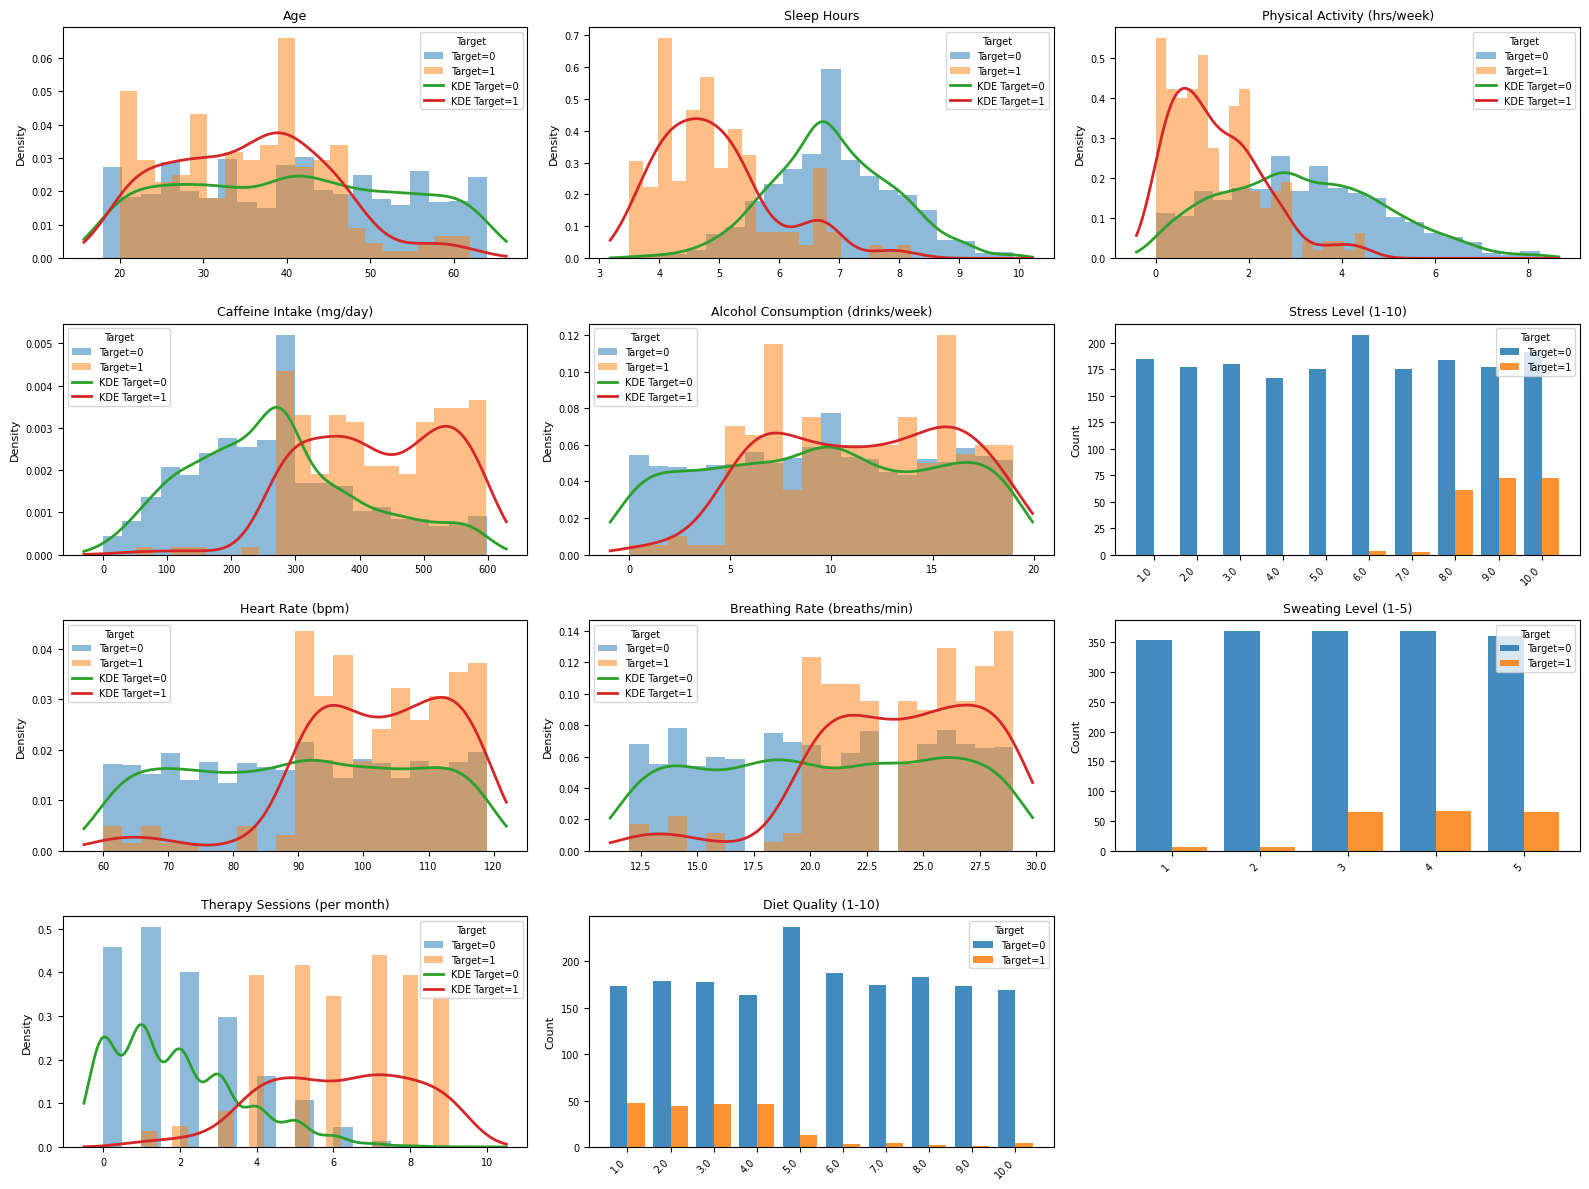

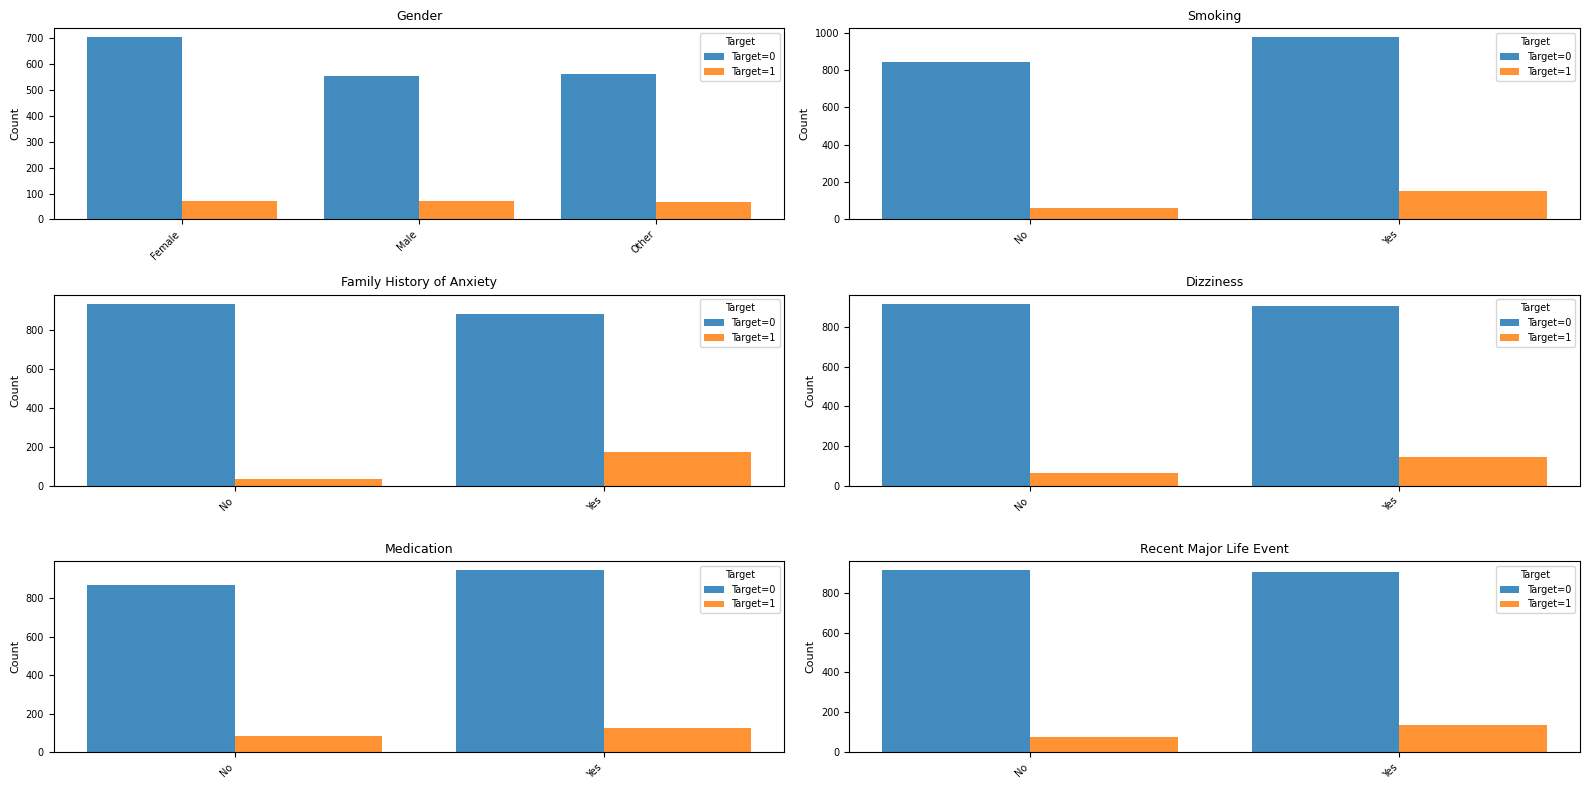

In [6]:
uplot.draw_plots_grid(df, NUM_COLS, target_col="Target", n_cols=3, figsize=(16, 12))
uplot.draw_plots_grid(df, CAT_COLS, target_col="Target", n_cols=2)

<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<div style="direction: rtl; text-align: right; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
بررسی دومتغیره بصورت بروت فورس
</h3>

<p style="direction: rtl; text-align: right;">

</p>

</p>

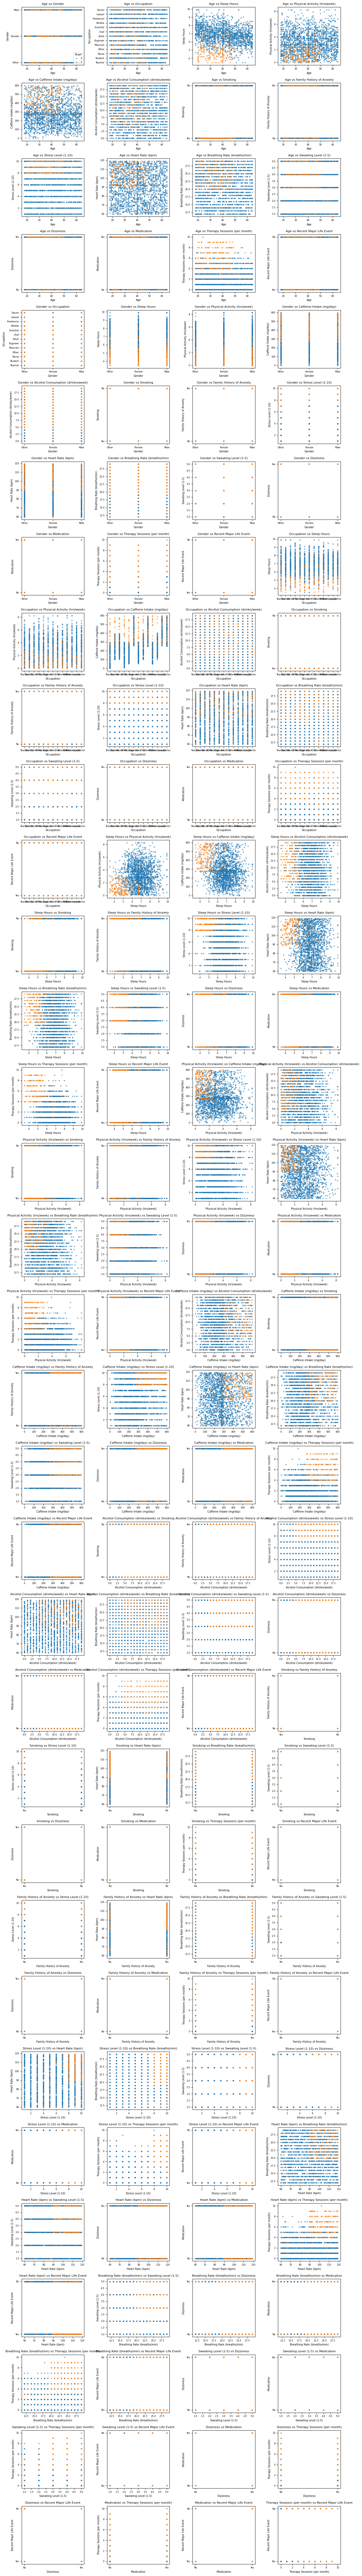

In [7]:
uplot.draw_scatter_pairs_grid_mpl(df, list(df.columns[:17]),
                            target_col="Target", n_cols=4)

<div style="direction: rtl; text-align: right; font-size: 18px; line-height: 2; font-family: Vazirmatn, IRANSans, sans-serif; width: 100%;">

<div style="direction: rtl; text-align: right; width: 100%;">

<h3 style="direction: rtl; text-align: right;">
بررسی سه‌متغیر بصورت انتخابی
</h3>

<p style="direction: rtl; text-align: right;">

</p>

</p>

In [8]:
uplot.draw_scatter_3d(df,'Sleep Hours','Physical Activity (hrs/week)','Stress Level (1-10)')
uplot.draw_scatter_3d(df,'Physical Activity (hrs/week)','Therapy Sessions (per month)', 'Diet Quality (1-10)')
uplot.draw_scatter_3d(df,'Physical Activity (hrs/week)','Sleep Hours', 'Diet Quality (1-10)')



<div dir="rtl" style="text-align: right;">

# چند ویژگی ترکیبی

## 1. نسبت کافئین به خواب (`Caffeine_to_Sleep_Ratio`)

- **منطق علمی:** چرخه معیوب کافئین و بی‌خوابی یکی از محرک‌های اصلی حملات پانیک است. خواب کم باعث کاهش آستانه تحمل سیستم عصبی می‌شود و ورود کافئین در این حالت، به جای افزایش تمرکز، مستقیماً به علائم فیزیکی اضطراب (مانند تپش قلب) تبدیل می‌شود.

- **مقاله مرجع:**
  - Winston, A. P., Hardwick, E., & Jaberi, N. (2005). *Neuropsychiatric effects of caffeine*. **Advances in Psychiatric Treatment, 11**(6), 432–439.

---

## 2. شاخص فرسودگی روانی (`Burnout_Ratio`)

این ویژگی از ترکیب دو ستون **`Stress Level (1-10)`** و **`Sleep Hours`** ساخته می‌شود.

- **منطق تحلیلی و علمی:** بدن انسان برای پردازش و پاکسازی بار هیجانی و استرس روزانه، به‌شدت به خواب، به‌ویژه مراحل مختلف خواب، وابسته است. استرس بالا به‌تنهایی ممکن است قابل مدیریت باشد، اما «استرس بالا به همراه خواب کم» می‌تواند باعث شود سیستم عصبی فرصت کافی برای ریکاوری نداشته باشد و فرد در معرض فرسودگی روانی و افزایش علائم اضطرابی قرار گیرد. با تقسیم استرس بر ساعات خواب، این وضعیت به یک شاخص عددی تبدیل می‌شود؛ به‌گونه‌ای که مقدار بالاتر نشان‌دهنده ترکیب نامطلوب‌تر استرس و خواب است.

- **مقاله مرجع:**
  - Åkerstedt, T. (2006). *Psychosocial stress and impaired sleep*. **Scandinavian Journal of Work, Environment & Health, 32**(6), 493–501.

---

## 3. شاخص جامع سلامت (`Wellness_Index`)

- **منطق علمی:** ارزیابی سلامت روان نیازمند در نظر گرفتن مجموعه‌ای از عوامل خطر و عوامل محافظت‌کننده است. ترکیب عواملی مانند تغذیه، خواب و فعالیت بدنی با عواملی مانند استرس و عادت‌های ناسالم می‌تواند یک شاخص جامع‌تر از وضعیت سبک زندگی و سلامت فرد ایجاد کند و در تحلیل رابطه میان سبک زندگی و سلامت روان مورد استفاده قرار گیرد.

- **مقاله مرجع:**
  - Velten, J., Bieda, A., Scholten, S., Wannemüller, A., & Margraf, J. (2018). *Lifestyle choices and mental health: a longitudinal survey with German and Chinese students*. **BMC Public Health, 18**(1), 1–15.



</div>

In [9]:
# 1
df['Caffeine_to_Sleep_Ratio'] = df['Caffeine Intake (mg/day)'] / df['Sleep Hours']

#2
df['Burnout_Ratio'] = df['Stress Level (1-10)'] / df['Sleep Hours']

#3
cond_smoke = (df['Smoking'] == 'Yes').astype(int)
cond_alcohol = (df['Alcohol Consumption (drinks/week)'] > df['Alcohol Consumption (drinks/week)'].median()).astype(int)
cond_caffeine = (df['Caffeine Intake (mg/day)'] > df['Caffeine Intake (mg/day)'].median()).astype(int)
cond_activity = (df['Physical Activity (hrs/week)'] < df['Physical Activity (hrs/week)'].median()).astype(int)
df['Unhealthy_Habits_Score'] = cond_smoke + cond_alcohol + cond_caffeine + cond_activity
scaler = MinMaxScaler()
cols_to_scale = ['Diet Quality (1-10)', 'Physical Activity (hrs/week)', 'Sleep Hours', 
                 'Stress Level (1-10)', 'Unhealthy_Habits_Score']
scaled_df = pd.DataFrame(scaler.fit_transform(df[cols_to_scale]), columns=cols_to_scale)
positive_components = scaled_df['Diet Quality (1-10)'] + scaled_df['Physical Activity (hrs/week)'] + scaled_df['Sleep Hours']
negative_components = scaled_df['Stress Level (1-10)'] + scaled_df['Unhealthy_Habits_Score']
df['Wellness_Index'] = positive_components - negative_components


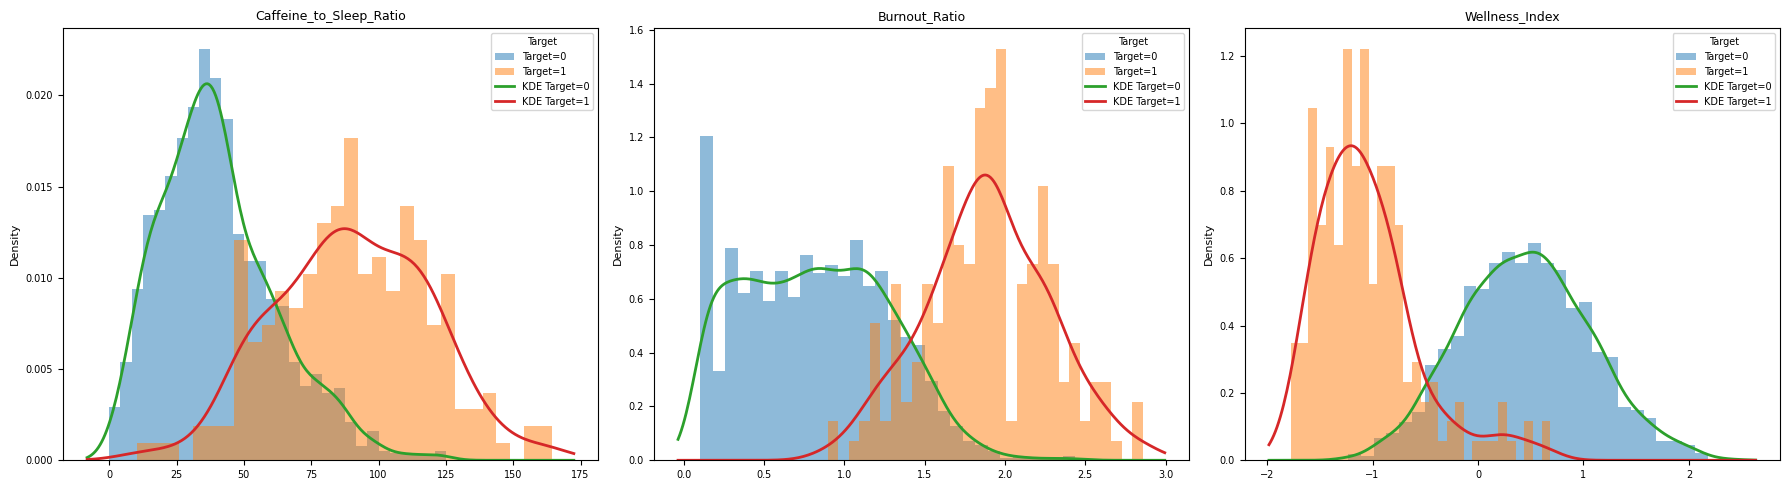

In [10]:
eng_features = ['Caffeine_to_Sleep_Ratio', 'Burnout_Ratio', 'Wellness_Index']

uplot.draw_plots_grid(
    df=df,
    cols=eng_features,
    target_col='Target',
    n_cols=3,             
    figsize=(18, 5),     
    plot_bins=30,          
    plt_type='histogram', 
    kde_plot=True         
)

<div dir="rtl" style="text-align: right;">

# تحلیل و بررسی اولیه

ابتدا قبل از وارد جزییات شدن, چند مورد تحلیلی که ساده تر هستند را بررسی میکنیم.

</div>

<div dir="rtl" style="text-align: right;">

## 1. سطح کیفیت تغذیه و بررسی اضطراب

با تبدیل نمرات پیوسته به دو دسته رژیم خوب و بد، به وضوح مشاهده می‌شود که نرخ ابتلا به اضطراب در دسته رژیم ضعیف چندین برابر دسته رژیم خوب است.
</p>


</div>

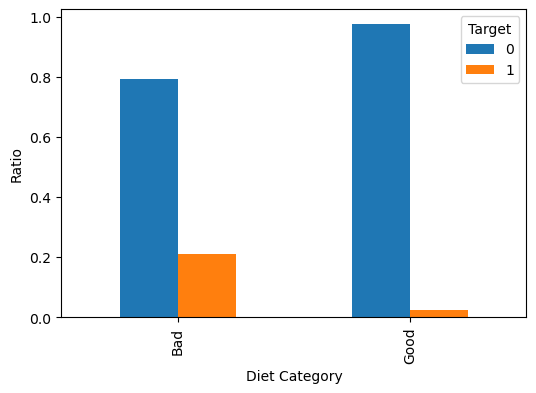

In [11]:
df['Diet_Binary'] = df['Diet Quality (1-10)'].apply( 
    lambda x : 'Good' if (x >= 5) else 'Bad'
)


dietDF = pd.crosstab(df['Diet_Binary'], df['Target'], normalize='index')

ax = dietDF.plot(
    kind='bar', 
    figsize=(6, 4), 
)

plt.xlabel('Diet Category')
plt.ylabel('Ratio')
plt.show()

<div dir="rtl" style="text-align: right;">

با توجه به اینکه متغیر اول که نوع رژیم هست, کتگوریکال است و متغیر هدف که تارگت است نیز کتگوریکال میباشد,
از آزمون Chi-Squared استفاده می‌کنیم تا استقلال یا عدم استقلال را در آن بررسی کنیم.

فرض صفر ($H_0$): کیفیت رژیم غذایی و وضعیت اضطراب کاملا از یکدیگر مستقل هستند. اگر در نمودار می‌بینیم که حدود ۲۰ درصد از افراد با رژیم بد مضطرب هستند در حالی که این آمار برای رژیم خوب نزدیک به صفر است، این اختلاف فقط ناشی از شانس و خطای نمونه‌گیری است و در کل جامعه صدق نمی‌کند.


فرض مقابل ($H_1$): کیفیت رژیم غذایی و وضعیت اضطراب به هم وابسته‌اند. تفاوت فاحشی که در نرخ ابتلا به اضطراب بین دو گروه رژیم بد و خوب مشاهده می‌شود، یک الگوی واقعی و معنادار است که در کل جامعه نیز وجود دارد.

</div>

In [12]:
contingency_table = pd.crosstab(df['Diet_Binary'], df['Target'])
contingency_table

Target,0,1
Diet_Binary,,
Bad,695,183
Good,1125,27


In [13]:
chi2_stat, p_value, dof, expected_table = stats.chi2_contingency(contingency_table)
print(f"آماره کای دو: {chi2_stat:.4f}")
print(f"درجه آزادی: {dof}")
print(f"p-value: {p_value:.4f}")
if p_value < ALPHA:
    print("فرض صفر رد می‌شود.")
else:
    print("فرض صفر رد نمی‌شود.")

آماره کای دو: 181.8561
درجه آزادی: 1
p-value: 0.0000
فرض صفر رد می‌شود.


<div dir="rtl" style="text-align: right;">

با توجه به اینکه فرض 0 رد شده است, یعنی این الگویی که یافتیم معنادار است و صرفا ناشی از خطا و نمونه گیری ما نیست.

</div>

In [14]:
count_low = contingency_table.loc['Bad', 1]
n_low = contingency_table.loc['Bad'].sum()

count_high = contingency_table.loc['Good', 1]
n_high = contingency_table.loc['Good'].sum()

ci_low_bottom, ci_low_top = proportion_confint(count=count_low, nobs=n_low, alpha=ALPHA, method='normal')
ci_high_bottom, ci_high_top = proportion_confint(count=count_high, nobs=n_high, alpha=ALPHA, method='normal')

print(f"بازه اطمینان ۹۵٪ برای ریسک اضطراب در رژیم ضعیف: [{ci_low_bottom:.3f}, {ci_low_top:.3f}]")
print(f"بازه اطمینان ۹۵٪ برای ریسک اضطراب در رژیم خوب: [{ci_high_bottom:.3f}, {ci_high_top:.3f}]")

بازه اطمینان ۹۵٪ برای ریسک اضطراب در رژیم ضعیف: [0.182, 0.235]
بازه اطمینان ۹۵٪ برای ریسک اضطراب در رژیم خوب: [0.015, 0.032]


<div dir="rtl" style="text-align: right;">

## 2. نسبت اضطراب در شغل‌ها

اینجا دیگه با مقایسه‌ی یک متغیر عددی پیوسته بین دو گروه طرف نیستیم. داریم نسبت (proportion) مضطرب‌بودن رو بین دو گروه Occupation مقایسه می‌کنیم. برای همین نه t-test جواب می‌ده و نه Mann-Whitney U (اونا برای متغیر عددی پیوسته‌ان). آزمون درست Chi-Squared روی جدول ۲×۲ هم هست؛ برای اطمینان هر دو رو محاسبه می‌کنیم.


اما ابتدا دوست داریم که دو گروه شغلی که بیشترین تفاوت را دارند را محاسبه کنیم
</p>


</div>

In [15]:
propDF = pd.crosstab(df['Occupation'], df['Target'], normalize='index')
counts = df['Occupation'].value_counts().rename('Total')
result = propDF.join(counts)
result = result.rename(columns={0: 'Target = 0', 1: 'Target = 1'})
result.sort_values(by='Target = 1',inplace=True)
result

,Target = 0,Target = 1,Total
Occupation,,,
Freelancer,0.947761,0.052239,134
Nurse,0.919753,0.080247,162
Student,0.912088,0.087912,182
Doctor,0.900621,0.099379,161
Other,0.899329,0.100671,149
Chef,0.897260,0.102740,146
Musician,0.895706,0.104294,163
Lawyer,0.892216,0.107784,167
Athlete,0.891156,0.108844,147


<div dir="rtl" style="text-align: right;">

با توجه به این مقادیر, بیشترین اختلاف بین فرد فریلنسر و معلم است.

$H_0$: نسبت مضطرب‌ها در دو گروه (فریلنسر و معلم) برابر است

$H_1$: این دو نسبت با هم فرق دارند

</p>


</div>

In [16]:
df_job = df[df['Occupation'].isin(['Teacher', 'Freelancer'])]
df_job = pd.crosstab(df_job['Occupation'], df_job['Target'], normalize='index')
df_job

Target,0,1
Occupation,,
Freelancer,0.947761,0.052239
Teacher,0.867550,0.132450


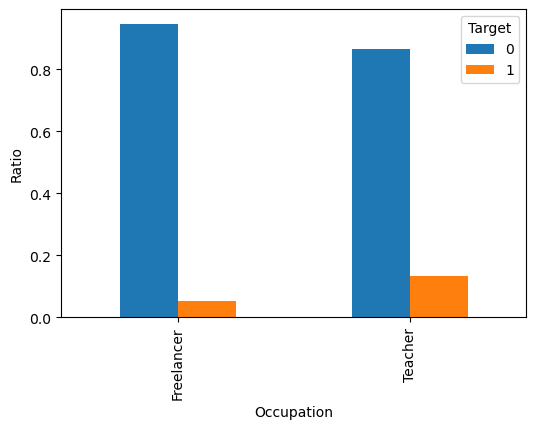

In [17]:

ax = df_job.plot(
    kind='bar', 
    figsize=(6, 4), 
)
plt.xlabel('Occupation')
plt.ylabel('Ratio')
plt.show()

In [18]:
job_df = df[df['Occupation'].isin(['Teacher', 'Freelancer'])]
contingency_table = pd.crosstab(job_df['Occupation'], job_df['Target'])
contingency_table

Target,0,1
Occupation,,
Freelancer,127,7
Teacher,131,20


In [19]:
chi2_stat, p_value, dof, expected_table = stats.chi2_contingency(contingency_table)
print(f"آماره کای دو: {chi2_stat:.4f}")
print(f"درجه آزادی: {dof}")
print(f"p-value: {p_value:.4f}")
if p_value < ALPHA:
    print("فرض صفر رد می‌شود.")
else:
    print("فرض صفر رد نمی‌شود.")

آماره کای دو: 4.4320
درجه آزادی: 1
p-value: 0.0353
فرض صفر رد می‌شود.


<div dir="rtl" style="text-align: right;">

با توجه به اینکه فرض 0 رد شده است, یعنی این الگویی که یافتیم معنادار است و صرفا ناشی از خطا و نمونه گیری ما نیست.
(این فرض در گروه های دیگر لزوما صدق نمیکند. به عنوان مثال اختلاف در گروه های پزشک و دانشجو, صرفا ناشی از 
نمونه ماست و در آزمون فرض آن, نمیتوانیم فرض 0 را رد کنیم)

</div>

In [20]:
count_low = contingency_table.loc['Teacher', 1]
n_low = contingency_table.loc['Teacher'].sum()

count_high = contingency_table.loc['Freelancer', 1]
n_high = contingency_table.loc['Freelancer'].sum()

ci_low_bottom, ci_low_top = proportion_confint(count=count_low, nobs=n_low, alpha=ALPHA, method='normal')
ci_high_bottom, ci_high_top = proportion_confint(count=count_high, nobs=n_high, alpha=ALPHA, method='normal')

print(f"بازه اطمینان ۹۵٪ برای ریسک اضطراب در شغل معلم: [{ci_low_bottom:.3f}, {ci_low_top:.3f}]")
print(f"بازه اطمینان ۹۵٪ برای ریسک اضطراب در شغل فریلنسر: [{ci_high_bottom:.3f}, {ci_high_top:.3f}]")

بازه اطمینان ۹۵٪ برای ریسک اضطراب در شغل معلم: [0.078, 0.187]
بازه اطمینان ۹۵٪ برای ریسک اضطراب در شغل فریلنسر: [0.015, 0.090]


<div dir="rtl" style="text-align: right;">

## 3. رابطه بین میزان خواب و اضطراب

در این قسمت اثر خواب را در اضطراب بررسی می‌کنیم
</p>


</div>

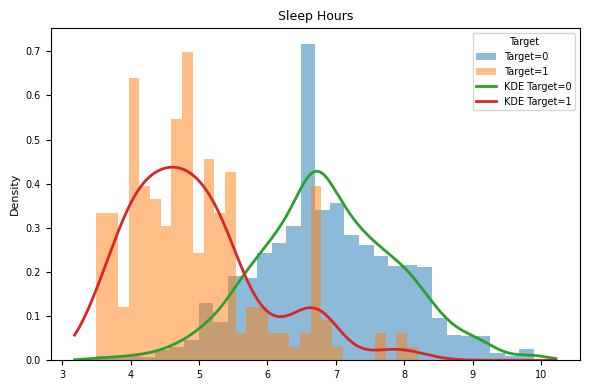

In [21]:
uplot.draw_plots_grid(
    df=df,
    cols=['Sleep Hours'],
    target_col='Target',
    n_cols=1,             
    figsize=(6, 4),     
    plot_bins=30,          
    plt_type='histogram', 
    kde_plot=True         
)

<div dir="rtl" style="text-align: right;">


حال میخواهیم با آزمون های آماری میانگین ساعت خواب در گروه مضطرب و غیرمضطرب را بررسی کنیم.
قدم اول بررسی نرمال بودن با استفاده از آزمون Shapiro-Wilk می‌باشد.

$H_0$: داده‌ها توزیع نرمال دارند

$H_1$: داده از توزیع نرمال ندارند


</p>


</div>

In [22]:
sleep_healthy = df[df['Target'] == 0]['Sleep Hours']
sleep_anxious = df[df['Target'] == 1]['Sleep Hours']

stat_0, p_val_0 = stats.shapiro(sleep_healthy)
stat_1, p_val_1 = stats.shapiro(sleep_anxious)

print(f"Target=0 -> stats: {stat_0:.3f}, p-value: {p_val_0:.3f}")
print(f"Target=0 -> stats: {stat_1:.3f}, p-value: {p_val_1:.3f}")

if (p_val_0 > ALPHA) :
    print("Target = 0: H0 accepted. Normal Dist Sleep Hour")
else:
    print("Target = 0: H0 rejected. Not Normal Dist Sleep Hour")

if (p_val_1 > ALPHA) :
    print("Target = 0: H0 accepted. Normal Dist Sleep Hour")
else:
    print("Target = 0: H0 rejected. Not Normal Dist Sleep Hour")


Target=0 -> stats: 0.997, p-value: 0.001
Target=0 -> stats: 0.928, p-value: 0.000
Target = 0: H0 rejected. Not Normal Dist Sleep Hour
Target = 0: H0 rejected. Not Normal Dist Sleep Hour


<div dir="rtl" style="text-align: right;">

هیچ کدام از توزیع نرمال پیروی نمی‌کنند بنابراین از آزمون غیر پارامتریک Mann-Whitney U استفاده می‌کنیم.
در این مرحله آزمونی یک طرفه طراحی میکنیم چراکه مطابق نمودار, میانگین ساعت خواب افراد غیرمضطرب از 
افراد مضطرب بیشتر بود.


$H_0$: ساعات خواب افراد سالم (Target=0) مساوی یا کمتر از افراد مضطرب است.

$H_1$: ساعات خواب افراد سالم به طور معناداری بیشتر از افراد مضطرب است.


</p>


</div>

In [23]:
stat_u, p_value = stats.mannwhitneyu(sleep_healthy, sleep_anxious, alternative='greater')

print(f"U-Statistic: {stat_u:.3f}")
print(f"P-value (One-Sided): {p_value:.3e}")

if p_value < 0.05:
    print("نتیجه: با اطمینان ۹۵٪ ثابت می‌شود که افراد غیرمضطرب، ساعات خواب بیشتری نسبت به افراد مضطرب دارند.")

U-Statistic: 346599.000
P-value (One-Sided): 1.154e-83
نتیجه: با اطمینان ۹۵٪ ثابت می‌شود که افراد غیرمضطرب، ساعات خواب بیشتری نسبت به افراد مضطرب دارند.




<div dir="rtl" style="text-align: right;">

در تحلیل متغیرهای پیوسته (مانند ساعات خواب) که توزیع آن‌ها از حالت نرمال خارج شده است، برای محاسبه بازه اطمینان ۹۵ درصدی 2 روش داریم. روش اول و پارامتریک و روش بوت‌استرپ. انتخاب بین این دو روش، یک ترید‌آف بین سرعت محاسبات و مقاومت در برابر خطاهای داده است.


</p>


</div>

In [24]:
def calculate_classic_ci(data):
    mean_val = np.mean(data)
    std_error = stats.sem(data) 
    ci_lower, ci_upper = stats.norm.interval(0.95, loc=mean_val, scale=std_error)
    return ci_lower, ci_upper

In [25]:
# Method1: Classic way - Not the best for skewed
ci_low_healthy, ci_high_healthy = calculate_classic_ci(sleep_healthy)
ci_low_anxious, ci_high_anxious = calculate_classic_ci(sleep_anxious)

print(f"بازه اطمینان ۹۵٪ میانگین خواب افراد سالم: [{ci_low_healthy:.2f}, {ci_high_healthy:.2f}]")
print(f"بازه اطمینان ۹۵٪ میانگین خواب افراد مضطرب: [{ci_low_anxious:.2f}, {ci_high_anxious:.2f}]")

بازه اطمینان ۹۵٪ میانگین خواب افراد سالم: [6.83, 6.92]
بازه اطمینان ۹۵٪ میانگین خواب افراد مضطرب: [4.80, 5.06]


In [26]:
# Method 2: Bootstrap
ci_healthy = stats.bootstrap(
    (sleep_healthy,), 
    statistic=np.median, 
    confidence_level=1-ALPHA, 
    method='percentile'
)

ci_anxious = stats.bootstrap(
    (sleep_anxious,), 
    statistic=np.median, 
    confidence_level=1-ALPHA, 
    method='percentile'
)

print(f"افراد سالم (Target=0):   [{ci_healthy.confidence_interval.low:.2f} , {ci_healthy.confidence_interval.high:.2f}] ساعت")
print(f"افراد مضطرب (Target=1): [{ci_anxious.confidence_interval.low:.2f} , {ci_anxious.confidence_interval.high:.2f}] ساعت")

افراد سالم (Target=0):   [6.70 , 6.90] ساعت
افراد مضطرب (Target=1): [4.60 , 4.90] ساعت




<div dir="rtl" style="text-align: right;">

نکته مهم این است که در حالتی که بازه هارا محاسبه کردیم هم باز این بازه های ساعتی, با هم تداخلی نداشتند و 
برای افراد مضطرب کمتر از افراد غیرمضطرب بود که این موضوع, تاکید بر فرضیه ما دارد.

</p>


</div>

<div dir="rtl" style="text-align: right;">

# نمودار همبستگی

برای دیدن بصری همبستگی یک ویژگی با متغیر هدف باینری از نمودار محنی رگرسیون لجیستیک استفاده میکنیم.
رسم منحنی لجستیک (S-Curve) نیازمند یک محور X تک‌بُعدی است، زیرا صفحه نمایش ما دوبعدی است (یک بعد برای فیچر، یک بعد برای متغیر هدف). وقتی یک ویژگی تک‌ستونی مثل Wellness_Index داریم، مقادیر آن مستقیما روی محور X می‌نشیند. اما وقتی با ترکیب‌های ۲ ستونی یا ۳ ستونی مواجه می‌شویم، باید یک مپینگ انجام دهیم تا چند بعد را به یک عدد واحد مپ کنیم.
الگوریتم پشت صحنه برای متغیرهای چندستونی دقیقاً این ۳ مرحله را طی می‌کند:

۱. ترکیب خطی : ابتدا یک مدل LogisticRegression روی آن ۲ یا ۳ ستون آموزش داده می‌شود. مدل برای هر ستون یک وزن (Weight) پیدا می‌کند و آن‌ها را با هم جمع می‌زند. مثلا برای ترکیب (سن + خواب):

<div dir="ltr">


$$z = w_1(\text{Sleep}) + w_2(\text{Stress}) + b$$


</div>

۲. Sigmoid Mapping: عدد $z$ به دست آمده می‌تواند از منفی بی‌نهایت تا مثبت بی‌نهایت باشد. تابع سیگموید این عدد را می‌گیرد و آن را در یک بازه دقیق بین ۰ تا ۱ فشرده می‌کند:

<div dir="ltr">


$$P = \frac{1}{1 + e^{-z}}$$


</div>

۳. تبدیل به محور X: این عدد $P$ که همان احتمال جوینت مضطرب بودن است، به عنوان یک ویژگی جدید و تک‌بعدی روی محور X قرار می‌گیرد. حالا می‌توانیم منحنی لجستیک را بین این احتمال ترکیبی و وضعیت اضطراب افراد (محور Y) رسم کنیم. اگر مدل خوب کار کرده باشد، افرادی که Target=1 هستند باید احتمالات نزدیک به ۱ گرفته باشند و نقاط در دو گوشه بالا و پایین نمودار متمرکز شوند.

</div>

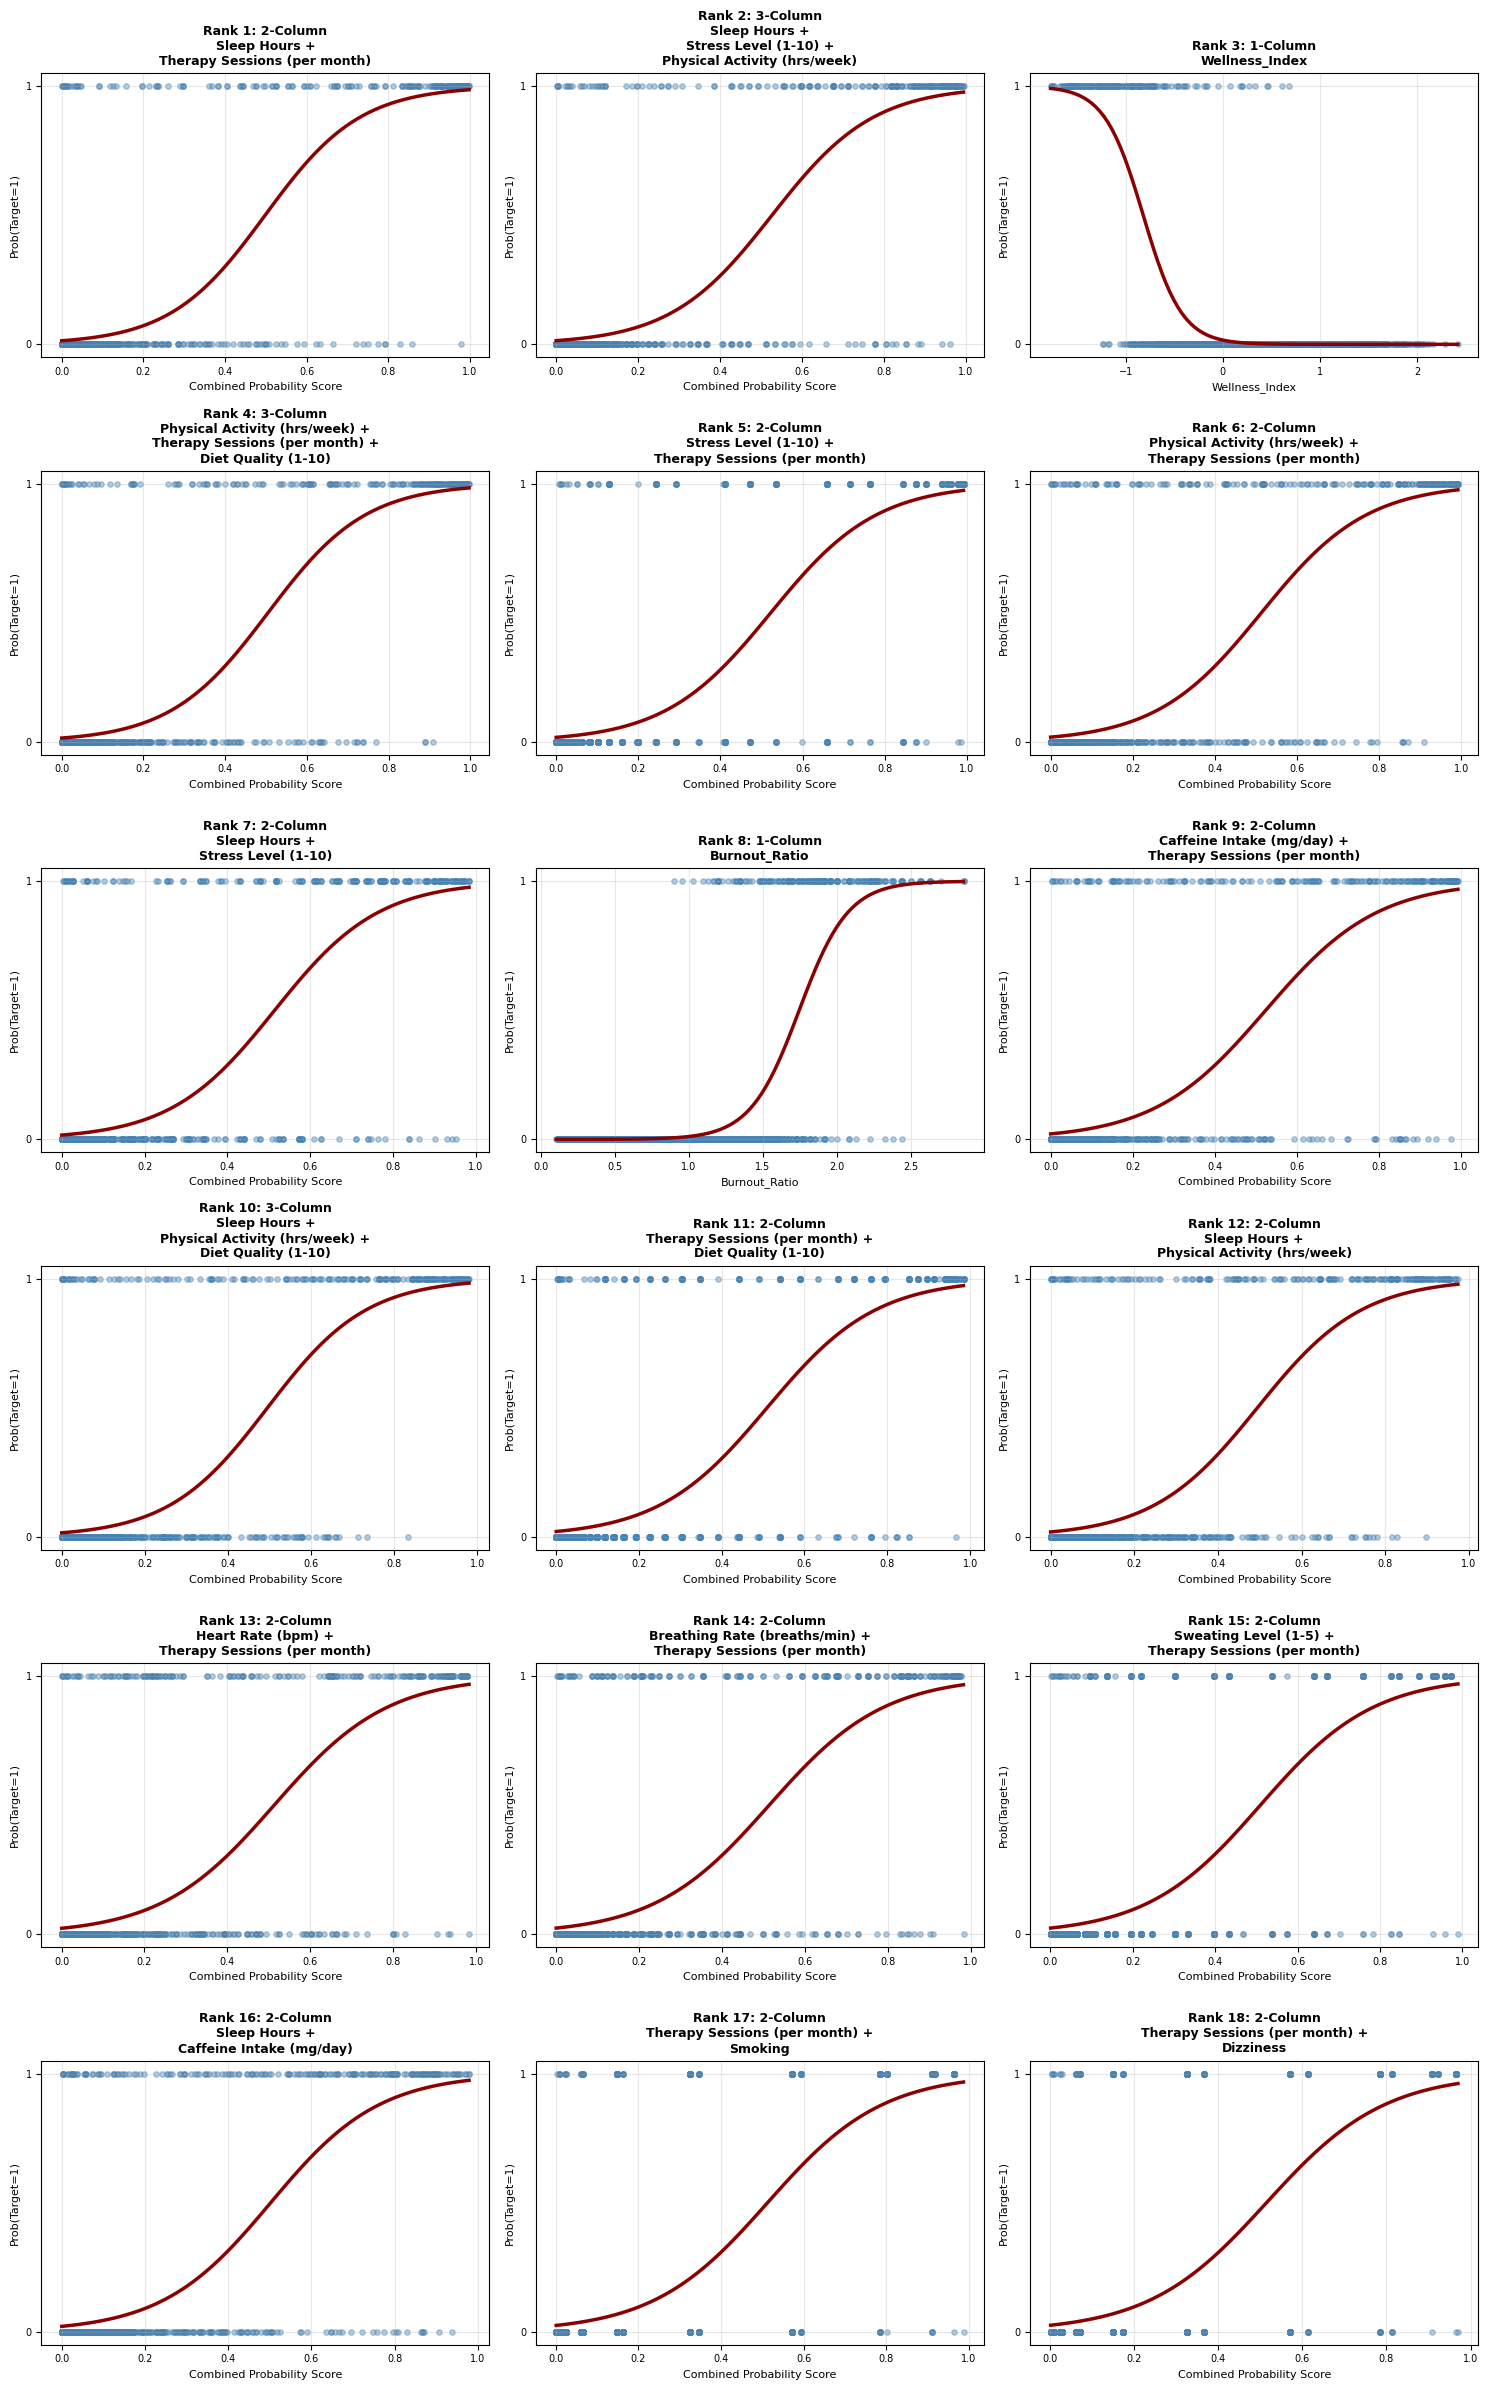

In [27]:
top_combinations = [
    ['Sleep Hours', 'Therapy Sessions (per month)'],
    ['Sleep Hours', 'Stress Level (1-10)', 'Physical Activity (hrs/week)'],
    ['Wellness_Index'],
    ['Physical Activity (hrs/week)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)'],
    ['Stress Level (1-10)', 'Therapy Sessions (per month)'],
    ['Physical Activity (hrs/week)', 'Therapy Sessions (per month)'],
    ['Sleep Hours', 'Stress Level (1-10)'],
    ['Burnout_Ratio'],
    ['Caffeine Intake (mg/day)', 'Therapy Sessions (per month)'],
    ['Sleep Hours', 'Physical Activity (hrs/week)', 'Diet Quality (1-10)'],
    ['Therapy Sessions (per month)', 'Diet Quality (1-10)'],
    ['Sleep Hours', 'Physical Activity (hrs/week)'],
    ['Heart Rate (bpm)', 'Therapy Sessions (per month)'],
    ['Breathing Rate (breaths/min)', 'Therapy Sessions (per month)'],
    ['Sweating Level (1-5)', 'Therapy Sessions (per month)'],
    ['Sleep Hours', 'Caffeine Intake (mg/day)'],
    ['Therapy Sessions (per month)', 'Smoking'],
    ['Therapy Sessions (per month)', 'Dizziness']
]

uplot.draw_logistic_curves_grid(
    df=df, 
    combinations_list=top_combinations, 
    target_col='Target', 
    n_cols=3, 
    figsize_per_cell=(5, 4)
)

<div dir="rtl" style="text-align: right;">

# محاسبه عددی همبستگی

ضریب همبستگی استاندارد (پیرسون) که با تابع df.corr() در پایتون محاسبه می‌شود، یک شرط دارد: هر دو متغیر باید پیوسته باشند.
متغیر هدف ما در اینجا مقادیر پیوسته ندارد بلکه کتگوریکال(باینری) است. فیت کردن یک خط راست روی داده‌های صفر و یک از نظر ریاضی اشتباه است (چون خط راست در نهایت مقادیر زیر صفر و بالای یک تولید می‌کند که برای احتمال مضطرب بودن بی‌معنی است). علاوه بر این، ضریب همبستگی عادی نمی‌تواند تعامل همزمانِ ۲ یا ۳ متغیر (مثلا ترکیب سن و خواب) را با هدف بسنجد و همچنین نمی‌تواند متغیرهای دسته‌ای (مثل جنسیت) را وارد محاسبه کند.

بنابراین از Pseudo R-Squared استفاده می‌کنیم

</div>

In [28]:
def get_power_score(feature_list):
  
    temp_df = df[feature_list + ['Target']].dropna()
    x = temp_df[feature_list]
    y = temp_df['Target']

    x = pd.get_dummies(x, drop_first=True, dtype=float)
    x = sm.add_constant(x) 
    
    model = sm.Logit(y, x).fit(disp=0)
    return model.prsquared

In [29]:
raw_columns = CAT_COLS + NUM_COLS

single_features = [[col] for col in raw_columns]
two_col_features = [list(comb) for comb in combinations(raw_columns, 2)]
three_col_features = [
    ['Sleep Hours', 'Stress Level (1-10)', 'Physical Activity (hrs/week)'],
    ['Physical Activity (hrs/week)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)'],
    ['Sleep Hours', 'Physical Activity (hrs/week)', 'Diet Quality (1-10)']
]
engineered_features = [['Burnout_Ratio'], ['Wellness_Index'], ['Caffeine_to_Sleep_Ratio']]

all_candidates = single_features + engineered_features + two_col_features + three_col_features

results = []
for candidate in all_candidates:
    score = get_power_score(candidate)
    name = " + ".join(candidate)
    category = "Engineered (Formula)" if candidate in engineered_features else f"{len(candidate)}-Column"
    results.append({
        'Feature / Combination': name,
        'Type': category,
        'Score': score
    })

results_df = pd.DataFrame(results).sort_values(
    by='Score', ascending=False
).reset_index(drop=True)

top20 = results_df.head(20)
top20

,Feature / Combination,Type,Score
0,Sleep Hours + Therapy Sessions (per month),2-Column,0.670090
1,Sleep Hours + Stress Level (1-10) + Physical A...,3-Column,0.667985
2,Wellness_Index,Engineered (Formula),0.659838
3,Physical Activity (hrs/week) + Therapy Session...,3-Column,0.639436
4,Stress Level (1-10) + Therapy Sessions (per mo...,2-Column,0.636920
5,Physical Activity (hrs/week) + Therapy Session...,2-Column,0.595894
6,Sleep Hours + Stress Level (1-10),2-Column,0.594225
7,Burnout_Ratio,Engineered (Formula),0.589300
8,Caffeine Intake (mg/day) + Therapy Sessions (p...,2-Column,0.580582
9,Sleep Hours + Physical Activity (hrs/week) + D...,3-Column,0.572494


<div dir="rtl" style="text-align: right;">

# تحلیل آماری

برای متغیرهای تک‌ستونی (مثل `Wellness_Index` یا `Burnout_Ratio`)، روش‌های ساده‌تری مثل آزمون **Mann-Whitney** می‌توانند برای بررسی ارتباط آن‌ها با اضطراب استفاده شوند.

اما وقتی  ترکیب‌ های ۲ یا ۳ ستونی (مثل خواب + استرس + فعالیت بدنی) داریم، آزمون‌های ساده‌تر معمولا نمی‌توانند اثر چند متغیر را **به‌صورت همزمان** در یک مدل بررسی کنند.

در این شرایط، **رگرسیون لجستیک (Logistic Regression یا Logit)** به ما اجازه می‌دهد اثر همزمان چند متغیر را روی یک متغیر هدف باینری بررسی کنیم. به همین دلیل، حتی متغیرهای تک‌ ستونی را نیز می‌توانیم وارد همین چارچوب کنیم تا نتایج همه ویژگی‌ ها با یک روش یکسان و قابل‌مقایسه تحلیل شوند.

### تعریف دقیق فرضیه‌های آماری

بنابراین از آزمون 
**والد (Wald Test)**
استفاده می‌کنیم

* **فرض صفر ($H_0$):** ضریب این ویژگی در مدل برابر با صفر است:

  <div dir="ltr">

  $$
  H_0:\beta_i=0
  $$

  </div>

  یعنی با توجه به سایر متغیرهای موجود در مدل، این ویژگی در مدل لجستیک ارتباط معناداری با خروجی ندارد.

* **فرض مقابل ($H_1$):** ضریب این ویژگی در مدل با صفر متفاوت است:

<div dir="ltr">

  $$
  H_1:\beta_i\neq0
  $$
</div>

  یعنی شواهد آماری وجود دارد که ضریب این ویژگی در مدل صفر نیست.

### استخراج ضرایب و اجرای آزمون والد

ما ابتدا 5 فیچر برتر با به logit میدهیم تا ضرایب را برای دانش خودمان پیدا کنیم. سپس **ضریب (Coefficient)** محاسبه‌شده برای هر متغیر را استخراج می‌کند و با استفاده از **P-value** مربوط به آزمون والد، بررسی می‌کند که آیا شواهد کافی برای رد فرض صفر وجود دارد یا خیر.

در صورتی که:

$$
P\text{-value}<0.05
$$

باشد، فرض صفر رد می‌شود و می‌توان گفت که برای ضریب موردنظر، شواهد آماری معناداری مبنی بر تفاوت آن از صفر وجود دارد.


</div>

In [30]:
top_candidates = {
    'Wellness Index (1-Col)': ['Wellness_Index'],
    'Sleep Hours + Stress Level + Activity (3-Col)': ['Sleep Hours', 'Stress Level (1-10)', 'Physical Activity (hrs/week)'],
    'Therapy + Sleep (2-Col)': ['Sleep Hours', 'Therapy Sessions (per month)'],
    'Therapy + Activity + Diet (3-Col)': ['Physical Activity (hrs/week)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)'],
    'Therapy + Stress (2-Col)': ['Stress Level (1-10)', 'Therapy Sessions (per month)']
}
results = []

for group_name, features in top_candidates.items():

    temp_df = df[features + ['Target']]
    x = temp_df[features]
    y = temp_df['Target']
    
    x = sm.add_constant(x)
    
    model = sm.Logit(y, x).fit(disp=0)
    
    coefficients = model.params
    p_values = model.pvalues
    
    for feature in features:
        coef = coefficients[feature]
        pval = p_values[feature]
        
        results.append({
            'Group': group_name,
            'Feature': feature,
            'Coefficient (Log-Odds)': round(coef, 4),
            'Coefficient (Odds Ratio)': np.exp(round(coef, 4)),
            'P-value': f"{pval:.4e}",
            'Significant': 'Yes' if pval < 0.05 else 'No'
        })
   

results_df = pd.DataFrame(results)
results_df


,Group,Feature,Coefficient (Log-Odds),Coefficient (Odds Ratio),P-value,Significant
0,Wellness Index (1-Col),Wellness_Index,-4.9963,0.006763,5.2530e-56,Yes
1,Sleep Hours + Stress Level + Activity (3-Col),Sleep Hours,-1.7498,0.173809,9.8748e-39,Yes
2,Sleep Hours + Stress Level + Activity (3-Col),Stress Level (1-10),0.7811,2.183873,2.0997e-19,Yes
3,Sleep Hours + Stress Level + Activity (3-Col),Physical Activity (hrs/week),-0.8661,0.420589,1.0239e-16,Yes
4,Therapy + Sleep (2-Col),Sleep Hours,-1.6193,0.198037,1.8162e-33,Yes
5,Therapy + Sleep (2-Col),Therapy Sessions (per month),0.9281,2.529698,5.8151e-41,Yes
6,Therapy + Activity + Diet (3-Col),Physical Activity (hrs/week),-0.8408,0.431365,4.2132e-18,Yes
7,Therapy + Activity + Diet (3-Col),Therapy Sessions (per month),0.9988,2.715022,2.2199e-48,Yes
8,Therapy + Activity + Diet (3-Col),Diet Quality (1-10),-0.3552,0.701033,6.0022e-12,Yes
9,Therapy + Stress (2-Col),Stress Level (1-10),0.7825,2.186933,1.8944e-20,Yes


<div dir="rtl" align="right">

# نحوه عملکردرگرسیون لجستیک 

توی مسائلی که جوابشون فقط دو حالته (مثلا اینکه طرف اضطراب داره یا نه)، الگوریتم های رگرسیون معمولی خیلی به کارمون نمیان چون احتمال همیشه یه عددی بین 0 و 1 هست. برای اینکه این محدودیت ریاضی رو دور بزنیم و بتونیم تاثیر دقیق هر ویژگی رو بسنجیم، رگرسیون لجستیک میاد داده ها رو میبره تو یه فضای محاسباتی بی نهایت و بعدش نتایج رو به یه زبون ساده تر یعنی «نسبت شانس» (Odds Ratio) برمیگردونه تا راحت تر بفهمیمش.

این تبدیل شدن سه تا مرحله اصلی داره:

## 1. رفتن به فضای لگاریتمی (Log-Odds که همان z که بالاتر محاسبه کردیم)
کامپیوترها برای اینکه بتونن خطوط رو رسم کنن و وزن دقیق هر متغیر رو پیدا کنن، به فضایی نیاز دارن که از منفی بی نهایت تا مثبت بی نهایت جا داشته باشه. برای شکستن اون مرز 0 و 1، اول مفهوم احتمال رو به شانس (Odds) تبدیل میکنیم (یعنی نسبت اتفاق افتادن یه چیزی به اتفاق نیفتادنش). بعد برای اینکه اعداد منفی رو هم پوشش بدیم (که نشون دهنده تاثیر کاهشی متغیرهاست)، از لگاریتم طبیعی استفاده میکنیم.
الگوریتم رگرسیون لجستیک میاد وزن خام یا همون ضریب هر ویژگی رو تو این فضای جدید (Log-Odds) حساب میکنه.

## 2. محاسبه بازه اطمینان 95 درصدی (Confidence Interval)
ضرایبی که به دست میان فقط بر اساس همین نمونه داده هایی هستن که ما داریم. برای اینکه بتونیم این نتایج رو به کل جامعه تعمیم بدیم باید از بازه اطمینان استفاده کنیم. طبق CLT، حتی اگه توزیع داده های اولیه ما نرمال نباشه، توزیع خطای محاسباتی این ضرایب همیشه شبیه یه زنگوله یا همون توزیع نرمال درمیاد.

توی توزیع نرمال استاندارد، دقیقا 95 درصد داده ها تو فاصله منفی 1.96 تا مثبت 1.96 انحراف معیار از مرکز قرار میگیرن. پس کران های بالا و پایین تو این فضای لگاریتمی با استفاده از خطای استاندارد (SE) اینطوری حساب میشن:

CI = Beta ± (1.96 × SE)

- ضریب Beta: همون عددی که مدل حساب کرده (لگاریتم شانس. دقیقا همون $w_i$ که توی $z=w_i\times feature_i$)
- خطای SE: خطای استاندارد ضریب
- عدد 1.96: مقدار بحرانی برای سطح اطمینان 95 درصد

## 3. برگشتن به دنیای واقعی (نمایی سازی)
اعداد مرحله قبل (مثل منفی 0.78 یا 1.2) خیلی معنی دار و قابل فهم نیستن. برای اینکه اثر لگاریتم رو خنثی کنیم و اعداد رو به یه مقیاس واقعی برگردونیم، از تابع نمایی با پایه e (عدد نپر) استفاده میکنیم.
وقتی کران های لگاریتمی رو به توان میرسونیم، اون ضرایب به نسبت شانس (Odds Ratio) تبدیل میشن:

CI (Odds Ratio) = e ^ (CI Log-Odds)

---

### چطوری نسبت شانس (Odds Ratio) رو تفسیر کنیم؟
خروجی نهایی این فرایند میشه یه ضریب و یه بازه اطمینان که بهمون میگه هر متغیر دقیقا چه تاثیری داره:

- **عوامل افزایش اضطراب (Odds Ratio بزرگتر از 1):** اگه نسبت شانس از 1 بیشتر باشه یعنی اون متغیر احتمال بروز هدف (مثل اضطراب) رو زیاد میکنه. مثلا اگه برای استرس عدد 2.18 رو داشته باشیم معنیش اینه که با هر یه واحد بیشتر شدن استرس، شانس ابتلا به اضطراب 2.18 برابر میشه.

- **عوامل کاهش اضطراب (Odds Ratio کوچکتر از 1):** اگه نسبت شانس کمتر از 1 باشه یعنی اون ویژگی نقش پیشگیری داره. مثلا عدد 0.17 برای خواب نشون میده که هرچی بیشتر بخوابیم شانس اضطراب کمتر میشه (کاهش 83 درصدی).

- **قانون بی اثر بودن (وقتی بازه از عدد 1 رد میشه):** عدد 1 تو نسبت شانس یعنی خنثی بودن کامل (مثل ضرب یه عدد در 1). اگه بازه اطمینان 95 درصدی یه ویژگی شامل عدد 1 باشه (مثلا کران پایینش 0.8 و کران بالاش 1.3 باشه)، از نظر آماری ثابت میشه که تاثیر اون ویژگی تو کل جامعه قطعی نیست و ممکنه اصلا هیچ تاثیری نداشته باشه.

</div>

In [31]:
results = []

for group_name, features in top_candidates.items():
    temp_df = df[features + ['Target']].dropna()
    x = sm.add_constant(temp_df[features])
    y = temp_df['Target']
    
    model = sm.Logit(y, x).fit(disp=0)

    odds_ratios = np.exp(model.params)
    

    conf_intervals = np.exp(model.conf_int(alpha=ALPHA))
    conf_intervals.columns = ['Lower_CI', 'Upper_CI']
    
    for feature in features:
        results.append({
            'Group': group_name,
            'Feature': feature,
            'Odds Ratio': round(odds_ratios[feature], 3),
            'Lower 95% CI': round(conf_intervals.loc[feature, 'Lower_CI'], 3),
            'Upper 95% CI': round(conf_intervals.loc[feature, 'Upper_CI'], 3)
        })
            

results_df = pd.DataFrame(results)
results_df


,Group,Feature,Odds Ratio,Lower 95% CI,Upper 95% CI
0,Wellness Index (1-Col),Wellness_Index,0.007,0.004,0.013
1,Sleep Hours + Stress Level + Activity (3-Col),Sleep Hours,0.174,0.134,0.226
2,Sleep Hours + Stress Level + Activity (3-Col),Stress Level (1-10),2.184,1.843,2.588
3,Sleep Hours + Stress Level + Activity (3-Col),Physical Activity (hrs/week),0.421,0.343,0.516
4,Therapy + Sleep (2-Col),Sleep Hours,0.198,0.152,0.258
5,Therapy + Sleep (2-Col),Therapy Sessions (per month),2.530,2.209,2.898
6,Therapy + Activity + Diet (3-Col),Physical Activity (hrs/week),0.431,0.357,0.522
7,Therapy + Activity + Diet (3-Col),Therapy Sessions (per month),2.715,2.375,3.104
8,Therapy + Activity + Diet (3-Col),Diet Quality (1-10),0.701,0.634,0.776
9,Therapy + Stress (2-Col),Stress Level (1-10),2.187,1.853,2.580
